In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

import pandas as pd
df = pd.read_excel("C:\\Users\\kaavy\\Data Model - Pizza Sales.xlsx")
df.head()


,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01,0.485139,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,0.498380,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,0.498380,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,0.498380,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,0.498380,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [3]:
print("Number of rows and columns in the dataset:")
print(df.shape,"\n")



print("MISSING VALUES \n")
print(df.isnull().sum())

Number of rows and columns in the dataset:
(48620, 12) 

MISSING VALUES 

order_details_id     0
order_id             0
pizza_id             0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64


In [5]:
print("INFO:")
print(df.info(),"\n")

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_details_id   48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_id           48620 non-null  object        
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[ns]
 5   order_time         48620 non-null  float64       
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  object        
 9   pizza_category     48620 non-null  object        
 10  pizza_ingredients  48620 non-null  object        
 11  pizza_name         48620 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(3), object(5)
memory usage: 4.5+ MB
None 



In [5]:
df['total_sales'] = df['quantity'] * df['unit_price']
print("Overall Sales for the year 2015:")
print(df['total_sales'].sum())

(df['total_price'] == df['total_sales']).all() 

Overall Sales for the year 2015:
817860.05


True

In [5]:
pizza_sales = df.groupby(['pizza_name', 'pizza_category', 'pizza_size']).agg({
    'quantity': 'sum',
    'total_price': 'sum',
    'unit_price': 'mean'
}).reset_index()
print(pizza_sales.head())
print("\n")
print("Number of rows and columns in the grouped dataset:")
print(pizza_sales.shape)

                   pizza_name pizza_category pizza_size  quantity  \
0  The Barbecue Chicken Pizza        Chicken          L       992   
1  The Barbecue Chicken Pizza        Chicken          M       956   
2  The Barbecue Chicken Pizza        Chicken          S       484   
3          The Big Meat Pizza        Classic          S      1914   
4        The Brie Carre Pizza        Supreme          S       490   

   total_price  unit_price  
0      20584.0       20.75  
1      16013.0       16.75  
2       6171.0       12.75  
3      22968.0       12.00  
4      11588.5       23.65  


Number of rows and columns in the grouped dataset:
(91, 6)


In [9]:
best_pizza = pizza_sales.sort_values(by='quantity', ascending=False).head(3)
worst_pizza = pizza_sales.sort_values(by='quantity', ascending=True).head(3)

print("Best Selling Pizza:\n", best_pizza, "\n")
print("Worst Selling Pizza:\n", worst_pizza, "\n")

Best Selling Pizza:
                 pizza_name pizza_category pizza_size  quantity  total_price  \
3       The Big Meat Pizza        Classic          S      1914      22968.0   
85  The Thai Chicken Pizza        Chicken          L      1410      29257.5   
20   The Five Cheese Pizza         Veggie          L      1409      26066.5   

    unit_price  
3        12.00  
85       20.75  
20       18.50   

Worst Selling Pizza:
                    pizza_name pizza_category pizza_size  quantity  \
27            The Greek Pizza        Classic        XXL        28   
28     The Green Garden Pizza         Veggie          L        95   
13  The Chicken Alfredo Pizza        Chicken          S        96   

    total_price  unit_price  
27      1006.60       35.95  
28      1923.75       20.25  
13      1224.00       12.75   



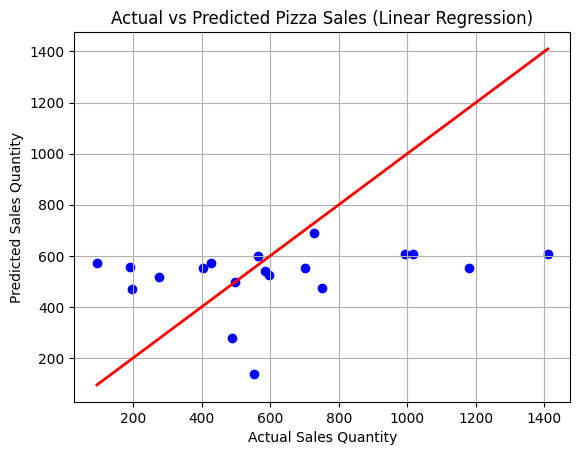

In [13]:
le_cat = LabelEncoder()
le_size = LabelEncoder()
pizza_sales['pizza_category_encoded'] = le_cat.fit_transform(pizza_sales['pizza_category'])
pizza_sales['pizza_size_encoded'] = le_size.fit_transform(pizza_sales['pizza_size'])
X = pizza_sales[['unit_price', 'pizza_category_encoded', 'pizza_size_encoded']]
y = pizza_sales['quantity']
model = LinearRegression()
model.fit(X, y)
pizza_sales['predicted_sales'] = model.predict(X)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel("Actual Sales Quantity")
plt.ylabel("Predicted Sales Quantity")
plt.title("Actual vs Predicted Pizza Sales (Linear Regression)")
plt.grid(True)
plt.show()



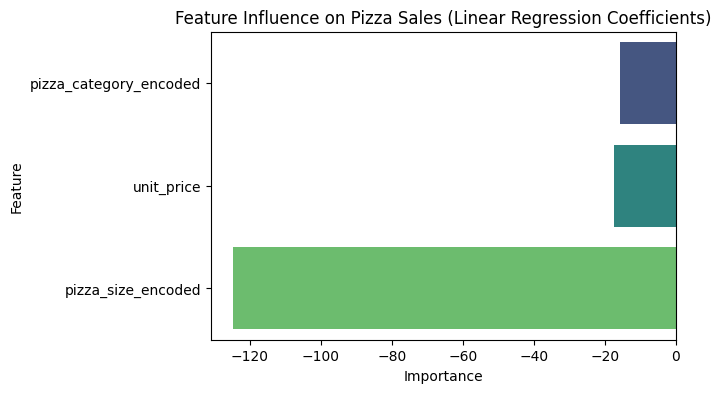

Insights & Predictions:

 Best Selling Pizza: 'The Big Meat Pizza'
- Price: 12.0, Category: Classic, Size: S
- Possible reasons for high sales:
  1. Affordable or good value for its size.
  2. Popular flavor or customer favorite category.
  3. Balanced price-to-quantity ratio.

Worst Selling Pizza: 'The Greek Pizza'
- Price: 35.95, Category: Classic, Size: XXL
- Possible reasons for low sales:
  1. High price compared to competitors.
  2. Less popular flavor or category.
  3. Unfavorable size (too small or too large).
  4. Needs better marketing or placement on the menu.



In [15]:
best_name = best_pizza.iloc[0]['pizza_name']
worst_name = worst_pizza.iloc[0]['pizza_name']

best_price = best_pizza.iloc[0]['unit_price']
worst_price = worst_pizza.iloc[0]['unit_price']

best_category = best_pizza.iloc[0]['pizza_category']
worst_category = worst_pizza.iloc[0]['pizza_category']

best_size = best_pizza.iloc[0]['pizza_size']
worst_size = worst_pizza.iloc[0]['pizza_size']

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Feature', data=coeff_df, hue='Feature',palette='viridis')
plt.title("Feature Influence on Pizza Sales (Linear Regression Coefficients)")
plt.show()

print("Insights & Predictions:\n")

print(f" Best Selling Pizza: '{best_name}'")
print(f"- Price: {best_price}, Category: {best_category}, Size: {best_size}")
print("- Possible reasons for high sales:")
print("  1. Affordable or good value for its size.")
print("  2. Popular flavor or customer favorite category.")
print("  3. Balanced price-to-quantity ratio.\n")

print(f"Worst Selling Pizza: '{worst_name}'")
print(f"- Price: {worst_price}, Category: {worst_category}, Size: {worst_size}")
print("- Possible reasons for low sales:")
print("  1. High price compared to competitors.")
print("  2. Less popular flavor or category.")
print("  3. Unfavorable size (too small or too large).")
print("  4. Needs better marketing or placement on the menu.\n")

Top 5 Most Common Ingredients:
          ingredient  count
0             Garlic  27422
1           Tomatoes  26601
2         Red Onions  19547
3        Red Peppers  16284
4  Mozzarella Cheese  10333 



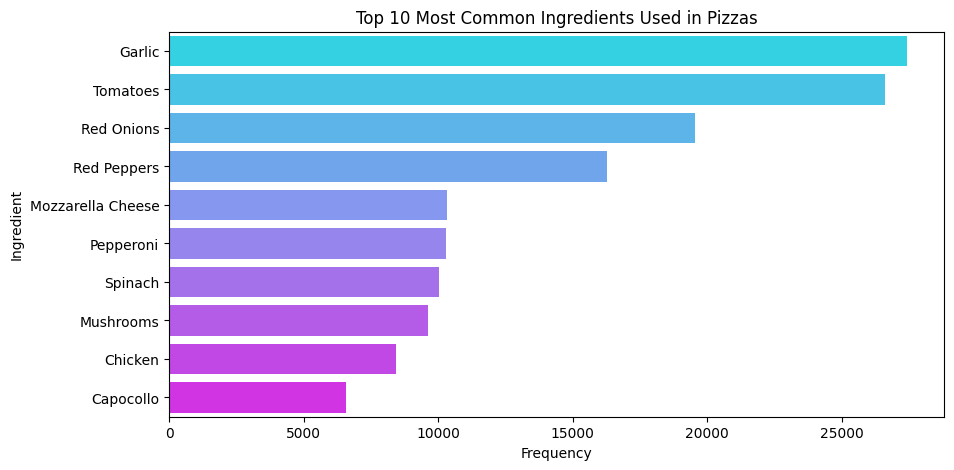

In [17]:
all_ingredients = df['pizza_ingredients'].str.split(',').explode().str.strip()
ingredient_count = all_ingredients.value_counts().reset_index()
ingredient_count.columns = ['ingredient', 'count']
print("Top 5 Most Common Ingredients:")
print(ingredient_count.head(), "\n")

plt.figure(figsize=(10,5))
sns.barplot(x='count',y='ingredient', data=ingredient_count.head(10), hue='ingredient', palette='cool')

plt.title("Top 10 Most Common Ingredients Used in Pizzas")
plt.xlabel("Frequency")
plt.ylabel("Ingredient")
plt.show()


In [30]:
print(" Suggestions to Improve Sales:\n")

if worst_price > best_price:
    print(f" '{worst_name}' is priced higher than '{best_name}'.")
    print("→ Try offering limited-time discounts or coupons to attract new buyers.")
else:
    print(f" '{worst_name}' has a similar or lower price than the best seller.")
    print("→ Focus on marketing and visibility on the menu instead of price reduction.")

if 'L' in worst_size or 'XL' in worst_size:
    print("Large-sized pizzas tend to sell less.")
    print("→ Introduce combo offers (e.g., 'Buy 1 Large, Get 1 Small Free') or family meal bundles.")
else:
    print(" For smaller sizes, try combo deals with drinks or desserts to increase order value.")

print("\nFlavor Improvement Suggestion:")
print(f"→ The top 5 most common ingredients across all pizzas are:\n{ingredient_count.head().to_string(index=False)}")
print(f"\n→ Consider adding one or more of these popular ingredients to '{worst_name}' to improve its flavor appeal.")


 Suggestions to Improve Sales:

 'The Greek Pizza' is priced higher than 'The Big Meat Pizza'.
→ Try offering limited-time discounts or coupons to attract new buyers.
Large-sized pizzas tend to sell less.
→ Introduce combo offers (e.g., 'Buy 1 Large, Get 1 Small Free') or family meal bundles.

Flavor Improvement Suggestion:
→ The top 5 most common ingredients across all pizzas are:
       ingredient  count
           Garlic  27422
         Tomatoes  26601
       Red Onions  19547
      Red Peppers  16284
Mozzarella Cheese  10333

→ Consider adding one or more of these popular ingredients to 'The Greek Pizza' to improve its flavor appeal.
